In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE

In [3]:
# Load Dataset

data = pd.read_csv("D:/Documents/Documents/Data_Analytics/PROJECT/Resume Projects/Credit Card Fraud Detection/dataset/creditcard.csv")

In [4]:
# Understand Dataset

print("\nFirst 5 Rows:")
print(data.head())

print("\nDataset Info:")
print(data.info())

print("\nClass Distribution:")
print(data['Class'].value_counts())



First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26      

In [5]:
#Preprocessing

In [6]:
scaler = StandardScaler()
data['Amount'] = scaler.fit_transform(data[['Amount']])

In [7]:
# Create time-based features
data['Hour'] = (data['Time'] // 3600) % 24

In [8]:
# Drop original Time
data = data.drop('Time', axis=1)

In [9]:
#EDA - Basic Plots

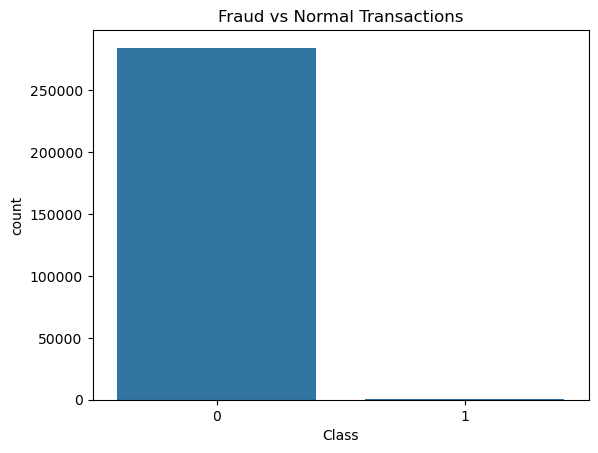

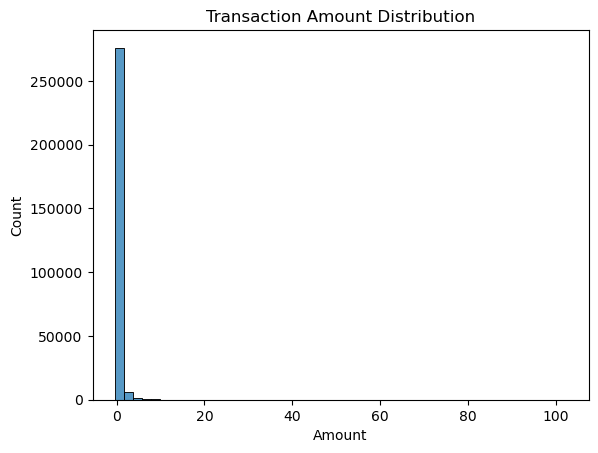

In [10]:
sns.countplot(x='Class', data=data)
plt.title("Fraud vs Normal Transactions")
plt.show()

sns.histplot(data['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()


### 1. Fraud vs Normal Transactions

- The dataset is **highly imbalanced**:
  - Normal transactions (Class = 0) dominate the dataset
  - Fraud transactions (Class = 1) are extremely rare
- This imbalance indicates:
  - A model can achieve high accuracy by predicting "normal" only
  - Accuracy is **not a reliable metric** for this problem
- This justifies the need for:
  - Techniques like **SMOTE**
  - Evaluation metrics such as **Recall, Precision, and F1-score**

---

### 2. Transaction Amount Distribution

- The distribution is **heavily right-skewed**:
  - Most transactions are of **very small amounts**
  - Very few transactions have high values
- Key observations:
  - Fraud is not necessarily linked to high transaction amounts
  - Small transactions dominate real-world financial behavior
- Implication:
  - Feature scaling is important (already applied)
  - Models should not rely solely on transaction amount

---

### 3. Overall Interpretation

- The dataset reflects a **real-world fraud scenario**:
  - Rare fraudulent events
  - Large volume of normal activity
- Key challenges:
  - Detecting fraud in a highly imbalanced dataset
  - Avoiding bias toward majority class

---

In [11]:
# GROUP BY ANALYSIS


Fraud Count by Hour:
Hour
0.0      6
1.0     10
2.0     57
3.0     17
4.0     23
5.0     11
6.0      9
7.0     23
8.0      9
9.0     16
10.0     8
11.0    53
12.0    17
13.0    17
14.0    23
15.0    26
16.0    22
17.0    29
18.0    33
19.0    19
20.0    18
21.0    16
22.0     9
23.0    21
Name: Class, dtype: int64


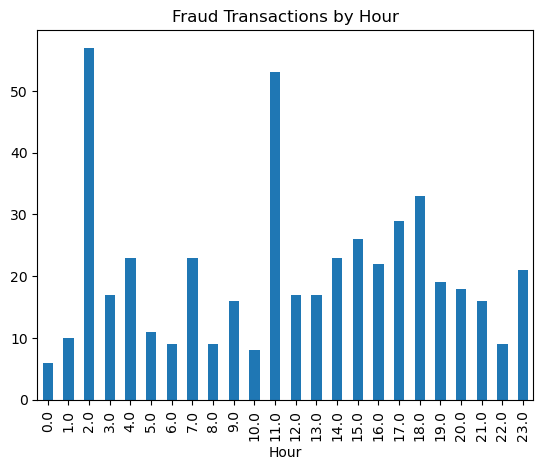


Average Transaction Amount by Class:
Class
0   -0.000234
1    0.135382
Name: Amount, dtype: float64


In [12]:
print("\nFraud Count by Hour:")
fraud_by_hour = data.groupby('Hour')['Class'].sum()
print(fraud_by_hour)

fraud_by_hour.plot(kind='bar', title="Fraud Transactions by Hour")
plt.show()

print("\nAverage Transaction Amount by Class:")
print(data.groupby('Class')['Amount'].mean())

### 1. Peak Fraud Hours

- Fraud activity is **highest during early morning hours**:
  - Around **2 AM (57 cases)** — highest peak
  - Around **11 AM (53 cases)** — secondary peak
- Moderate activity observed during:
  - **5 PM – 6 PM (29–33 cases)**

---

### 2. Low Fraud Activity Periods

- Lowest fraud occurrences:
  - **Midnight (0 AM): 6 cases**
  - **6 AM – 10 AM range: generally low**
- Indicates relatively safer transaction periods

---

### 3. Behavioral Pattern Insight

- Fraud tends to occur more during:
  - **Off-peak or low-monitoring hours (late night / early morning)**
- Possible reasons:
  - Reduced user attention
  - Lower real-time monitoring
  - Automated fraudulent activity

---

### 4. Average Transaction Amount by Class

- Normal transactions (Class = 0): **-0.000234**
- Fraud transactions (Class = 1): **0.135382**

**Important Note:**
- These values are **scaled**, not actual currency amounts
- Fraud transactions have a **higher average value (after scaling)** compared to normal ones

**Insight:**
- Fraudulent transactions tend to be **slightly higher in value**
- However, the difference is not extremely large
- This indicates:
  - Fraud is **not only limited to high-value transactions**
  - Amount alone is **not a strong predictor**

---

### 5. Business Implications

- Institutions can:
  - Increase monitoring during **high-risk hours**
  - Combine **time + transaction amount + other features** for detection
- Relying on a single factor (like amount) is insufficient

---

### 6. Conclusion

- Fraud shows clear **time-based patterns**
- Fraud transactions tend to have **slightly higher scaled amounts**
- Effective fraud detection requires:
  - **Multiple features**
  - **Balanced models**
  - **Time-aware analysis**

In [13]:
# PIVOT TABLE ANALYSIS


Pivot Table (Avg Amount by Hour & Class):
Class         0         1
Hour                     
0.0   -0.112799  0.859570
1.0   -0.103424  0.158254
2.0   -0.072957 -0.036330
3.0   -0.144272 -0.298218
4.0   -0.044812 -0.084106
5.0   -0.151777  0.161677
6.0   -0.093525  0.094254
7.0   -0.082749  0.126155
8.0    0.001829 -0.161770
9.0    0.058045 -0.039527
10.0   0.084898  0.821014
11.0   0.084833  0.142437
12.0   0.070333  0.447926
13.0   0.042285  0.162872
14.0   0.060422  0.279706
15.0   0.054674 -0.009688
16.0   0.059963  0.465551
17.0   0.039748  0.111858
18.0  -0.045258  0.415511
19.0  -0.041595  0.091743
20.0  -0.055233 -0.017743
21.0  -0.066696 -0.095978
22.0  -0.074070  0.287353
23.0  -0.078329  0.245174


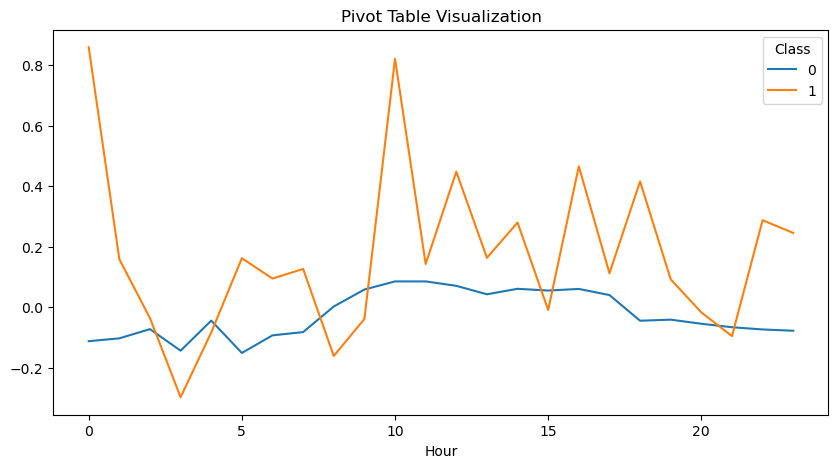

In [14]:
pivot_table = pd.pivot_table(
    data,
    values='Amount',
    index='Hour',
    columns='Class',
    aggfunc='mean'
)

print("\nPivot Table (Avg Amount by Hour & Class):")
print(pivot_table)

pivot_table.plot(figsize=(10,5), title="Pivot Table Visualization")
plt.show()

In [15]:
#  Correlation Analysis

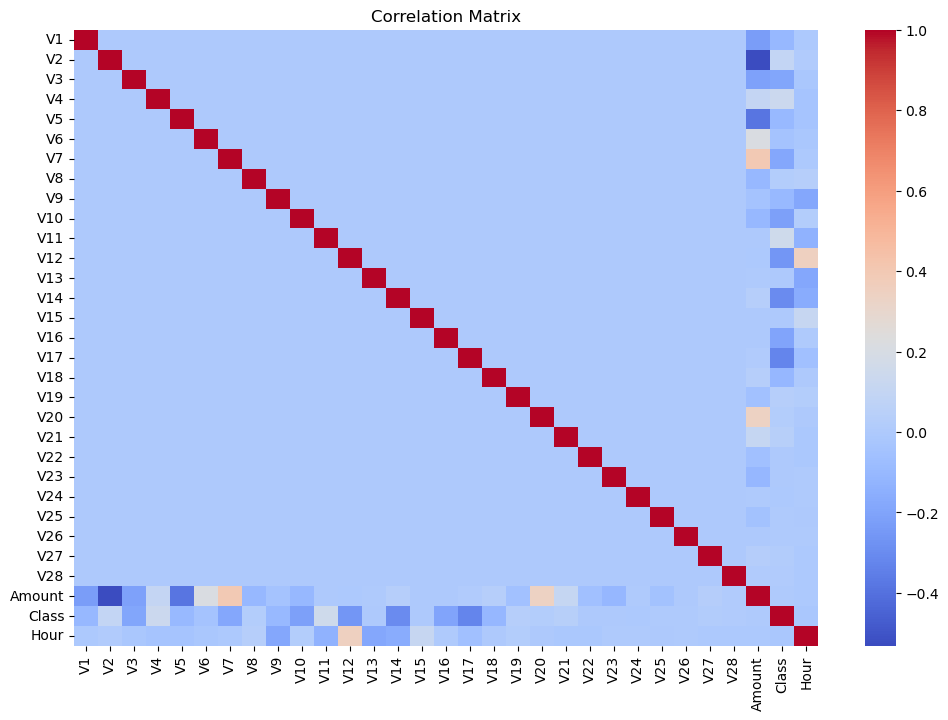

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


### 1. Feature Independence (V1–V28)

- Most features (V1–V28) show **very low correlation with each other**
- This indicates:
  - Features are largely **independent**
  - No strong multicollinearity present
- Reason:
  - These variables are generated using **PCA**, which produces uncorrelated components

---

### 2. Correlation with Target Variable (Class)

- Some features show **moderate positive or negative correlation** with fraud (`Class`)
- These features are important because:
  - They help the model distinguish between fraud and normal transactions
- However:
  - No feature has extremely high correlation → fraud detection is a **complex problem**

---

### 3. Amount and Hour Features

- `Amount` shows **slight correlation** with some features and the target
- `Hour` shows **very weak correlation** with most variables
- Insight:
  - These features alone are **not strong predictors**
  - But they add value when combined with other variables

---

### 4. No Strong Linear Relationships

- The absence of strong correlations suggests:
  - Relationships may be **non-linear**
- Implication:
  - Models like **Random Forest** perform better than linear models

---

### 5. Business Interpretation

- Fraud detection cannot rely on:
  - A single feature
  - Simple linear relationships
- Effective detection requires:
  - Combining multiple features
  - Using advanced models that capture complex patterns

---

### 6. Conclusion

- Features are **well-structured and non-redundant**
- Some variables are useful predictors of fraud
- The problem requires:
  - **Machine learning models**
  - Not just basic statistical rules

In [17]:
#Prepare Data
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
#Handle Imbalance (SMOTE)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("\nBalanced Class Distribution:")
print(pd.Series(y_res).value_counts())



Balanced Class Distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


### 1. Before SMOTE

- The dataset was **highly imbalanced**:
  - Normal transactions (Class = 0) dominated
  - Fraud transactions (Class = 1) were extremely rare
- This imbalance could lead to:
  - Biased models
  - Poor fraud detection performance

---

### 2. After Applying SMOTE

- Balanced class distribution achieved:
  - Class 0 (Normal): **227,451**
  - Class 1 (Fraud): **227,451**
- The dataset is now **perfectly balanced**

---

### 3. What SMOTE Did

- Generated **synthetic fraud samples**
- Did not duplicate existing data
- Created new data points based on patterns in minority class

---

### 4. Impact on Model Training

- Model now learns:
  - Fraud patterns more effectively
  - Balanced decision boundaries
- Improves:
  - **Recall (detecting fraud cases)**
  - Overall model robustness

---

### 5. Important Consideration

- SMOTE is applied **only on training data**
- Test data remains unchanged to:
  - Simulate real-world conditions
  - Ensure fair evaluation

---

### 6. Conclusion

- Class imbalance problem successfully resolved
- Model is now better equipped to:
  - Detect rare fraud cases
  - Avoid bias toward normal transactions

In [19]:
#Logistic Regression

In [20]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_res, y_res)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("\nLogistic Regression Results:")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Results:
[[55345  1519]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



### 1. Confusion Matrix Interpretation

- True Negatives (Correct Normal): **55,345**
- False Positives (Normal predicted as Fraud): **1,519**
- False Negatives (Missed Fraud): **8**
- True Positives (Correct Fraud): **90**

---

### 2. Key Performance Metrics

#### Class 0 (Normal Transactions)
- Precision: **1.00**
- Recall: **0.97**
- F1-score: **0.99**

#### Class 1 (Fraud Transactions)
- Precision: **0.06**
- Recall: **0.92**
- F1-score: **0.11**

---

### 3. Critical Observations

- **High Recall (0.92) for fraud detection**
  - The model successfully identifies most fraud cases
  - Only **8 fraud cases missed**, which is very good

- **Very Low Precision (0.06)**
  - Large number of false alarms (**1,519 false positives**)
  - Many normal transactions are incorrectly flagged as fraud

---

### 4. Accuracy is Misleading

- Accuracy = **97%**, but:
  - This is inflated due to class imbalance
  - Does not reflect true fraud detection performance

---

### 5. Business Interpretation

- The model is **aggressive in detecting fraud**
- Suitable when:
  - Missing fraud is very costly
- Not ideal when:
  - Too many false alerts affect user experience

---

### 6. Trade-off Analysis

- High Recall → Good fraud detection  
- Low Precision → Poor user experience (too many alerts)

---

### 7. Conclusion

- Logistic Regression performs well in:
  - **Capturing fraud cases (high recall)**
- But struggles with:
  - **Precision (too many false positives)**
- More advanced models (e.g., Random Forest) may provide better balance

In [22]:
#Random Forest

In [21]:
#
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_res, y_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\nRandom Forest Results:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Results:
[[56853    11]
 [   15    83]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



### 1. Confusion Matrix Interpretation

- True Negatives (Correct Normal): **56,853**
- False Positives (Normal predicted as Fraud): **11**
- False Negatives (Missed Fraud): **15**
- True Positives (Correct Fraud): **83**

---

### 2. Key Performance Metrics

#### Class 0 (Normal Transactions)
- Precision: **1.00**
- Recall: **1.00**
- F1-score: **1.00**

#### Class 1 (Fraud Transactions)
- Precision: **0.88**
- Recall: **0.85**
- F1-score: **0.86**

---

### 3. Critical Observations

- **High Precision (0.88)**
  - Very few false alarms (**only 11 false positives**)
  - Model is reliable when it flags fraud

- **Good Recall (0.85)**
  - Detects most fraud cases
  - Only **15 fraud cases missed**

- **Balanced Performance**
  - Strong trade-off between precision and recall
  - Much better than Logistic Regression

---

### 4. Accuracy and Reliability

- Accuracy ≈ **100%**
  - Unlike Logistic Regression, this is **not misleading here**
  - Supported by strong precision and recall

---

### 5. Comparison with Logistic Regression

| Metric        | Logistic Regression | Random Forest |
|--------------|--------------------|--------------|
| Precision    | 0.06               | 0.88         |
| Recall       | 0.92               | 0.85         |
| False Positives | 1519            | 11           |
| False Negatives | 8               | 15           |

Random Forest:
- Slightly lower recall  
- **Massively improved precision**

---

### 6. Business Interpretation

- Random Forest is **more practical for real-world deployment**
- Benefits:
  - Reduces unnecessary fraud alerts
  - Maintains strong fraud detection capability
- Suitable for:
  - Banking systems
  - Payment gateways

---

### 7. Conclusion

- Random Forest significantly outperforms Logistic Regression
- Provides:
  - **High precision**
  - **Good recall**
  - **Balanced performance**
- Best choice for fraud detection in this project

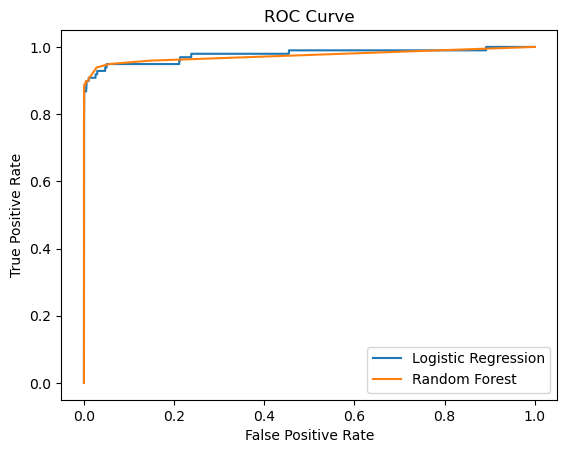

In [23]:
# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### 1. Understanding the ROC Curve

- ROC (Receiver Operating Characteristic) curve shows:
  - **True Positive Rate (Recall)** vs **False Positive Rate**
- A model closer to the **top-left corner** indicates better performance

---

### 2. Observations from the Graph

- Both **Logistic Regression** and **Random Forest** curves are:
  - Very close to the **top-left corner**
  - Indicating strong classification performance

- The curves for both models are **very similar**
  - Suggesting both models can distinguish between fraud and normal transactions effectively

---

### 3. Model Comparison

- **Random Forest slightly outperforms Logistic Regression**
  - Curve is marginally higher in key regions
- However, the difference is not very large in ROC space

---

### 4. Key Insight

- Despite similar ROC curves:
  - Logistic Regression had **poor precision**
  - Random Forest had **balanced performance**

 This shows:
- ROC alone is **not sufficient**
- Must consider:
  - Precision
  - Recall
  - Confusion matrix

---

### 5. Business Interpretation

- Both models are capable of:
  - Separating fraud from normal transactions
- But:
  - Random Forest is **more reliable in practice**
  - Due to fewer false positives

---

### 6. Conclusion

- ROC curves confirm that:
  - Both models are strong classifiers
- However:
  - **Random Forest remains the better choice**
  - Because it provides a better balance between detection and accuracy


Top 10 Important Features:
   Feature  Importance
13     V14    0.179049
11     V12    0.105553
9      V10    0.098161
3       V4    0.096000
16     V17    0.091145
10     V11    0.076754
15     V16    0.074118
2       V3    0.040245
6       V7    0.034066
8       V9    0.027944


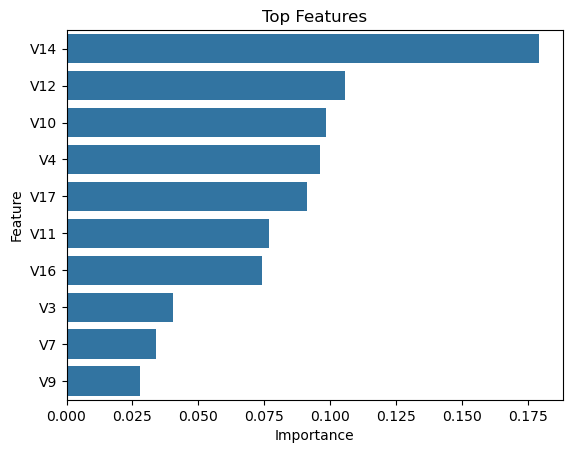

In [24]:
# Feature Importance
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feat_imp.head(10))

sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top Features")
plt.show()


### 1. Top Contributing Features

The most important features influencing fraud detection are:

1. **V14** (Highest importance: 0.179)
2. **V12**
3. **V10**
4. **V4**
5. **V17**
6. **V11**
7. **V16**
8. **V3**
9. **V7**
10. **V9**

---

### 2. Key Observations

- **V14 is the most influential feature**
  - Significantly higher importance than others
- Features like **V12, V10, V4, V17** also contribute strongly
- Importance gradually decreases across features
- Indicates that fraud detection depends on a **combination of multiple variables**

---

### 3. Interpretation of V Features

- These features are derived using **PCA (Principal Component Analysis)**
- Therefore:
  - They do not have direct real-world meanings
  - They represent **hidden patterns in transaction data**

---

### 4. Model Behavior Insight

- Random Forest prioritizes features that:
  - Best split fraud vs normal transactions
- High-importance features:
  - Capture strong signals of fraudulent behavior

---

### 5. Business Insight

- Fraud detection is driven by:
  - **complex patterns**, not simple rules
- No single feature alone determines fraud
- Effective detection requires:
  - Combining multiple signals

---

### 6. Conclusion

- A small subset of features contributes most to model decisions
- The model successfully identifies key patterns in anonymized data
- Feature importance enhances:
  - Model interpretability
  - Trust in predictions

In [25]:
#ROC AUC Score
print("\nROC AUC Scores:")
print("Logistic Regression:", roc_auc_score(y_test, y_prob_lr))
print("Random Forest:", roc_auc_score(y_test, y_prob_rf))


ROC AUC Scores:
Logistic Regression: 0.9775422813329044
Random Forest: 0.9743601453665316


### 1. ROC AUC Scores

- Logistic Regression: **0.978**
- Random Forest: **0.974**

---

### 2. Interpretation

- Both models have **very high AUC scores (close to 1.0)**
- This indicates:
  - Strong ability to **distinguish between fraud and normal transactions**
  - Excellent overall classification performance

---

### 3. Key Observation

- Logistic Regression has a **slightly higher AUC score**
- However, the difference is **very small and not significant**

---

### 4. Important Insight

 A higher AUC does **not necessarily mean a better model in practice**

- Logistic Regression:
  - High AUC
  - **Very low precision (many false positives)**

- Random Forest:
  - Slightly lower AUC
  - **Much better precision and balanced performance**

---

### 5. Business Interpretation

- AUC measures:
  - Overall ranking ability of the model
- But real-world systems care more about:
  - **False alarms (precision)**
  - **Missed fraud (recall)**

---

### 6. Conclusion

- Both models are strong classifiers based on AUC
- However:
  - **Random Forest is the better practical choice**
  - Due to its superior balance between precision and recall

## Key Insights

### 1. Class Imbalance is Critical
- Fraud transactions are extremely rare compared to normal ones  
- Without handling imbalance, models become biased toward normal transactions  
- Applying **SMOTE significantly improved fraud detection capability**

---

### 2. Fraud Detection Requires Trade-offs
- Logistic Regression:
  - High recall (detects most fraud)
  - Very low precision (too many false alerts)
- Random Forest:
  - Balanced precision and recall
  - More practical for real-world use

---

### 3. Fraud Patterns are Complex
- No single feature strongly determines fraud  
- Important features (V14, V12, V10, etc.) work **together**
- Relationships are **non-linear**, favoring tree-based models

---

### 4. Time-Based Patterns Exist
- Fraud occurrences vary across different hours  
- Higher activity during specific periods (e.g., early morning)  
- Time features can improve model performance

---

### 5. Transaction Amount Alone is Not Sufficient
- Fraud transactions have slightly higher average values (after scaling)  
- But overlap with normal transactions is significant  
- Amount must be used along with other features

---

### 6. High ROC AUC Does Not Guarantee Best Model
- Both models have high AUC (~0.97)  
- However:
  - Logistic Regression performs poorly in precision  
  - Random Forest performs better in real-world scenarios

---

### 7. Best Model for Deployment
- Random Forest provides:
  - High precision (fewer false alarms)
  - Good recall (detects most fraud)
- Most suitable for practical fraud detection systems

---

### 8. Overall Learning

- Fraud detection is:
  - A **highly imbalanced classification problem**
  - Requires **advanced models and careful evaluation**
- Success depends on:
  - Proper preprocessing
  - Correct evaluation metrics
  - Business-oriented interpretation